# Video Game Market Analysis

Use historical game sales and review scores to support a 2017 campaign-planning case for the online store Ice.

This public edition preserves the analysis in Portuguese. See the English README and VALIDATION.md for results, publication edits and reproduction limits.


In [ ]:
from pathlib import Path

# Resolve the same data directory from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
if not DATA_DIR.is_dir():
    raise FileNotFoundError("Open this notebook from the repository root or notebooks/ and follow data/README.md.")




Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>





## Estudo de caso: loja online Ice

**Objetivo:** identificar padrões que determinam se um jogo tem sucesso, a fim de apoiar o planejamento da campanha publicitária de **2017**.

### Plano do notebook
1. Abertura do arquivo e estudo inicial dos dados  
2. Preparação dos dados  
3. Análise exploratória  
4. Perfil de usuário por região  
5. Teste de hipóteses  
6. Conclusão geral

In [9]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [10]:
games = pd.read_csv(DATA_DIR / 'games.csv')
display(games.head())
games.info()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


## 1. Leitura inicial e observações

Na leitura inicial, alguns pontos importantes já aparecem:

- os nomes das colunas estão com letras maiúsculas e minúsculas misturadas;
- `year_of_release` foi lida como `float`;
- `user_score` foi lida como `object`, pois contém valores não numéricos como `TBD`;
- há valores ausentes em `name`, `genre`, `year_of_release`, `critic_score`, `user_score` e `rating`.

Esses pontos precisam ser tratados antes da análise.

In [11]:
games.columns = games.columns.str.lower()

print("Valores ausentes por coluna:")
display(games.isna().sum())

print("Quantidade de 'tbd' em user_score:")
print((games['user_score'] == 'tbd').sum())

Valores ausentes por coluna:


name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

Quantidade de 'tbd' em user_score:
2424


## 2. Preparação dos dados

### Decisões de limpeza e transformação

**Colunas em minúsculas**  
Padronizei os nomes das colunas para facilitar o trabalho e seguir boas práticas.

**Conversão de tipos**
- `year_of_release`: convertida para tipo numérico e depois para inteiro anulável (`Int64`), porque representa ano.
- `user_score`: convertida para numérico com `errors='coerce'`, para transformar `TBD` em `NaN`.
- `critic_score` já estava em formato numérico adequado.

**Tratamento de ausentes**
- Linhas sem `name`, `genre` ou `year_of_release` foram removidas, porque essas colunas são essenciais para identificar e analisar os jogos.
- Ausentes em `critic_score`, `user_score` e `rating` foram mantidos, pois preencher artificialmente essas colunas poderia distorcer a análise.

**Por que os valores podem estar ausentes?**
- jogo muito antigo, sem registro completo em fontes abertas;
- nota ainda não consolidada;
- classificação ESRB não atribuída ou não registrada;
- problemas de integração/coleta de dados.

**Sobre `TBD`**
`TBD` significa *to be determined*. Isso indica que a nota do usuário ainda não estava definida no momento da coleta. Portanto, esses valores não devem ser tratados como nota numérica. O procedimento mais adequado é convertê-los para ausentes (`NaN`).

In [12]:
games['year_of_release'] = pd.to_numeric(games['year_of_release'], errors='coerce').astype('Int64')
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

games = games.dropna(subset=['name', 'genre', 'year_of_release']).copy()

games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

display(games.head())
games.info()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
 11  total_sales      16444 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.6+ MB


### Resumo da preparação
Os dados já estão prontos para análise. A principal mudança foi tratar `TBD` corretamente, remover linhas sem identificação básica do jogo e criar a variável `total_sales`, que será usada como referência de vendas globais.

## 3. Análise dos dados
### 3.1 Quantidade de jogos lançados por ano

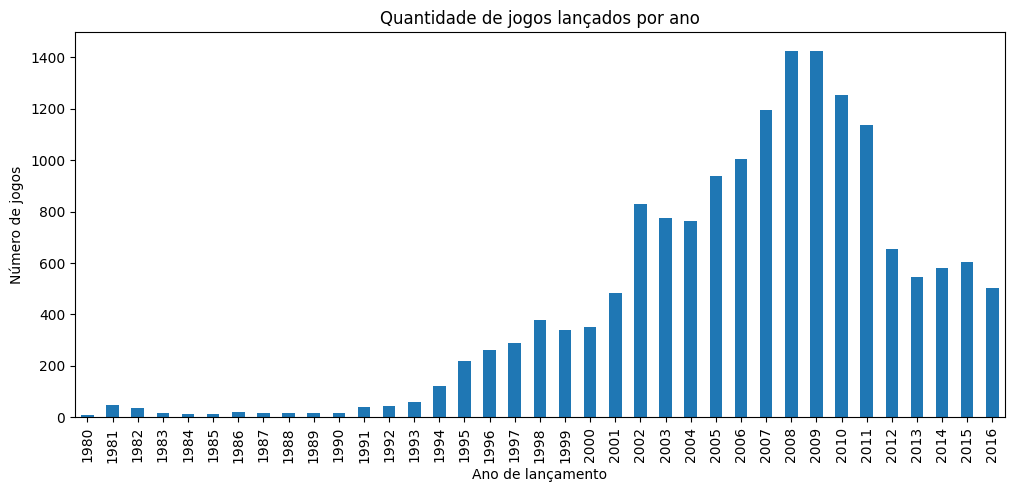

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
dtype: int64

In [13]:
games_per_year = games.groupby('year_of_release').size()

plt.figure(figsize=(12, 5))
games_per_year.plot(kind='bar')
plt.title('Quantidade de jogos lançados por ano')
plt.xlabel('Ano de lançamento')
plt.ylabel('Número de jogos')
plt.show()

display(games_per_year.sort_index())

### Comentário
Os dados mais antigos têm poucos registros, enquanto o volume cresce muito a partir dos anos 2000 e atinge o pico entre 2007 e 2009.  
Os dados de **2016** parecem menores e podem estar incompletos, como o próprio enunciado informa.

### 3.2 Vendas totais por plataforma e ciclo de vida das plataformas

In [ ]:
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
platform_sales.head(15).plot(kind='bar')
plt.title('Top 15 plataformas por vendas globais totais')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões de unidades)')
plt.show()

display(platform_sales.head(15))

In [ ]:
platform_year_sales = games.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

top_platforms = platform_sales.head(10).index
platform_year_sales[top_platforms].plot(figsize=(14, 6))
plt.title('Distribuição anual de vendas — principais plataformas')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões de unidades)')
plt.show()

In [16]:
platform_life = games.groupby('platform')['year_of_release'].agg(['min', 'max'])
platform_life['life_cycle'] = platform_life['max'] - platform_life['min']

display(platform_life.sort_values('life_cycle', ascending=False).head(15))
display(platform_life['life_cycle'].describe())

,min,max,life_cycle
platform,,,
PC,1985,2016,31
DS,1985,2013,28
GB,1988,2001,13
X360,2005,2016,11
PSP,2004,2015,11
PS2,2000,2011,11
NES,1983,1994,11
DC,1998,2008,10
Wii,2006,2016,10


count   31.00
mean     7.61
std      7.00
min      0.00
25%      3.00
50%      6.00
75%     10.00
max     31.00
Name: life_cycle, dtype: float64

### Comentário
As plataformas líderes em vendas históricas incluem **PS2, X360, PS3, Wii e DS**.  
Ao observar a série histórica, fica claro que plataformas têm ciclo de vida finito: surgem, crescem, atingem pico e depois perdem relevância.

Em média, o ciclo observado gira em torno de **7 a 8 anos**, embora haja exceções como **PC**, que permanece relevante por muito mais tempo.

### 3.3 Definição do período relevante para previsão de 2017
Para prever 2017, o ideal é usar um período mais recente, refletindo melhor o mercado atual.  
Considerando o comportamento das plataformas e a transição geracional, vou usar **2012–2016** como base analítica.

In [17]:
recent = games[games['year_of_release'] >= 2012].copy()
recent.shape

(2886, 12)

### 3.4 Plataformas líderes no período recente

In [ ]:
recent_platform_sales = recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
recent_platform_sales.head(10).plot(kind='bar')
plt.title('Top 10 plataformas em vendas globais (2012–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões de unidades)')
plt.show()

display(recent_platform_sales.head(10))

In [ ]:
recent_platform_year = recent.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

selected_platforms = recent_platform_sales.head(8).index
recent_platform_year[selected_platforms].plot(figsize=(14, 6))
plt.title('Evolução anual das vendas por plataforma (2012–2016)')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões de unidades)')
plt.show()

### Comentário
No período recente, **PS4, PS3, X360, 3DS e XOne** lideram em vendas.  
Entre elas:
- **PS4** e **XOne** representam a geração mais recente e, portanto, são candidatas naturais para campanhas de 2017;
- **PS3** e **X360** ainda vendem, mas estão claramente em queda;
- **3DS** continua relevante, sobretudo em mercados específicos como o Japão.

### 3.5 Boxplot das vendas globais por plataforma
Para não poluir o gráfico com plataformas muito pequenas, vou considerar as plataformas mais relevantes do período recente.

In [ ]:
popular_platforms = recent['platform'].value_counts()
popular_platforms = popular_platforms[popular_platforms >= 50].index

plt.figure(figsize=(14, 7))
recent[recent['platform'].isin(popular_platforms)].boxplot(
    column='total_sales',
    by='platform',
    figsize=(14, 7)
)
plt.title('Distribuição das vendas globais por plataforma (2012–2016)')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões de unidades)')
plt.ylim(0, 2)
plt.show()

In [21]:
platform_stats = recent[recent['platform'].isin(popular_platforms)].groupby('platform')['total_sales'].agg(
    ['count', 'mean', 'median', 'std', 'var']
).sort_values('mean', ascending=False)

display(platform_stats)

,count,mean,median,std,var
platform,,,,,
X360,292,0.81,0.31,1.71,2.93
PS4,392,0.80,0.20,1.61,2.59
Wii,54,0.65,0.18,1.17,1.36
XOne,247,0.65,0.22,1.04,1.07
PS3,493,0.59,0.20,1.46,2.14
WiiU,147,0.56,0.22,1.06,1.12
3DS,396,0.49,0.11,1.39,1.92
PC,250,0.25,0.08,0.49,0.24
PSV,411,0.12,0.05,0.20,0.04


### Comentário
As diferenças entre plataformas são relevantes.  
Em geral:
- há muita assimetria nas vendas, com poucos grandes sucessos e muitos jogos com vendas baixas;
- plataformas como **PS4**, **XOne** e **WiiU** tendem a ter médias maiores do que portáteis menores;
- a média costuma ser bem maior que a mediana, o que reforça a presença de outliers de grande sucesso.

### 3.6 Efeito das avaliações nas vendas — plataforma escolhida: PS4
Vou analisar a **PS4**, uma das plataformas mais relevantes para 2017.

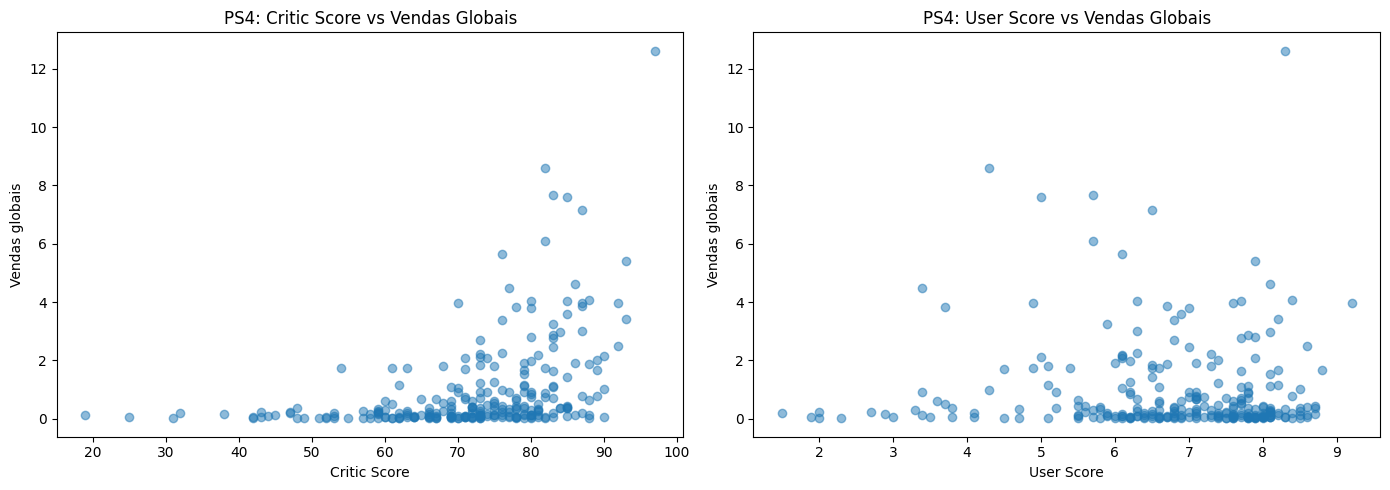

Correlação critic_score x total_sales (PS4): 0.40656790206178095
Correlação user_score x total_sales (PS4): -0.031957110204556376


In [22]:
ps4 = recent[recent['platform'] == 'PS4'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ps4['critic_score'], ps4['total_sales'], alpha=0.5)
axes[0].set_title('PS4: Critic Score vs Vendas Globais')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Vendas globais')

axes[1].scatter(ps4['user_score'], ps4['total_sales'], alpha=0.5)
axes[1].set_title('PS4: User Score vs Vendas Globais')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Vendas globais')

plt.tight_layout()
plt.show()

print('Correlação critic_score x total_sales (PS4):', ps4['critic_score'].corr(ps4['total_sales']))
print('Correlação user_score x total_sales (PS4):', ps4['user_score'].corr(ps4['total_sales']))

### Comentário
Na PS4:
- a correlação entre **critic_score** e vendas é **moderada e positiva**;
- a correlação entre **user_score** e vendas é **muito fraca**.

Isso sugere que a recepção da crítica especializada parece explicar melhor o desempenho comercial do que a nota de usuários.

### 3.7 Comparação dos mesmos jogos em outras plataformas
Vou comparar jogos que saíram na PS4 e em outras plataformas.

In [23]:
ps4_game_names = recent[recent['platform'] == 'PS4']['name'].unique()
same_games = recent[recent['name'].isin(ps4_game_names)]

same_games_mean_sales = same_games.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
display(same_games_mean_sales)

platform
Wii    1.12
X360   1.07
PS4    0.80
PS3    0.79
XOne   0.60
DS     0.38
WiiU   0.34
3DS    0.29
PC     0.26
PSV    0.14
PSP    0.12
Name: total_sales, dtype: float64

### Comentário
Entre jogos compartilhados com a PS4, plataformas como **X360**, **PS3** e **XOne** têm desempenho médio competitivo.  
Já **PC** tende a apresentar vendas médias menores para esses mesmos títulos. Isso sugere que o sucesso do mesmo jogo pode variar de forma importante conforme a base instalada e o perfil do público de cada plataforma.

### 3.8 Distribuição geral por gênero

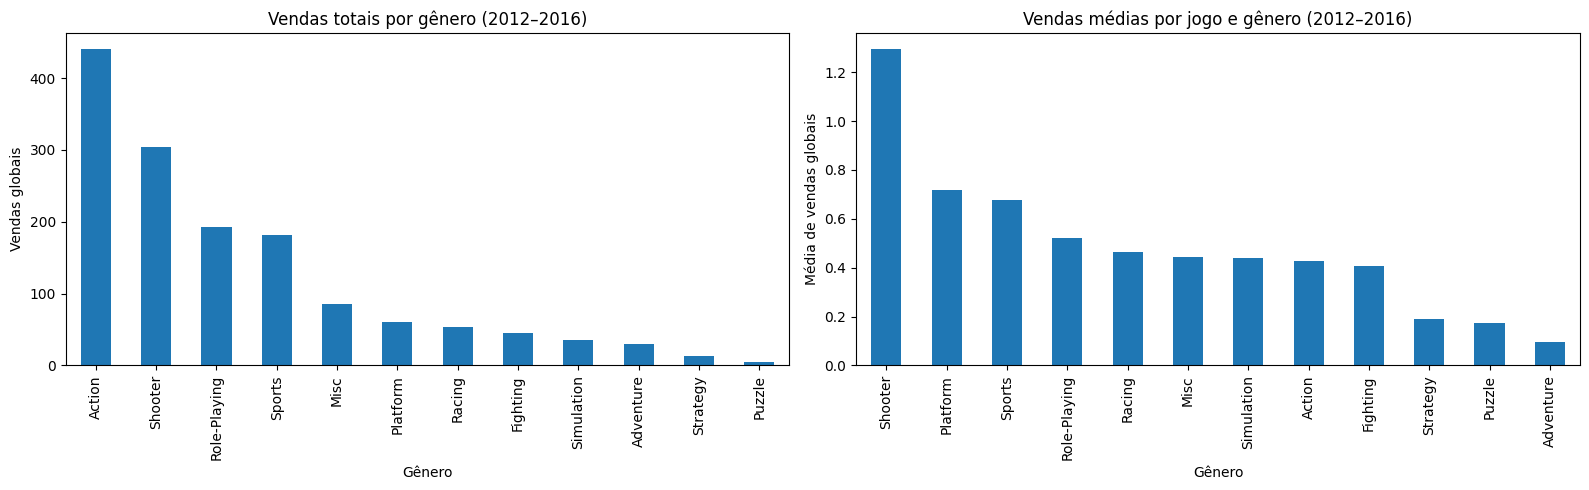

genre
Action         441.12
Shooter        304.73
Role-Playing   192.80
Sports         181.07
Misc            85.04
Platform        61.00
Racing          53.50
Fighting        44.49
Simulation      35.12
Adventure       29.43
Strategy        13.34
Puzzle           4.89
Name: total_sales, dtype: float64

genre
Shooter        1.30
Platform       0.72
Sports         0.68
Role-Playing   0.52
Racing         0.47
Misc           0.44
Simulation     0.44
Action         0.43
Fighting       0.41
Strategy       0.19
Puzzle         0.17
Adventure      0.10
Name: total_sales, dtype: float64

In [24]:
genre_sales = recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_mean_sales = recent.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_sales.plot(kind='bar', ax=axes[0], title='Vendas totais por gênero (2012–2016)')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Vendas globais')

genre_mean_sales.plot(kind='bar', ax=axes[1], title='Vendas médias por jogo e gênero (2012–2016)')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Média de vendas globais')

plt.tight_layout()
plt.show()

display(genre_sales)
display(genre_mean_sales)

### Comentário
- Em **volume total**, o gênero **Action** lidera.
- Em **vendas médias por jogo**, **Shooter** se destaca com mais força.
- Gêneros como **Adventure** e **Puzzle** apresentam desempenho mais fraco.

Portanto, não basta olhar apenas para o total vendido: alguns gêneros vendem muito porque têm muitos lançamentos, enquanto outros são mais eficientes em receita por jogo.

## 4. Perfil de usuário por região
Vou usar o período **2012–2016**, focando no contexto mais próximo de 2017.

In [25]:
regions = ['na_sales', 'eu_sales', 'jp_sales']

for region in regions:
    print('=' * 60)
    print(region.upper())
    print('\nTop 5 plataformas:')
    display(recent.groupby('platform')[region].sum().sort_values(ascending=False).head(5))
    
    print('Top 5 gêneros:')
    display(recent.groupby('genre')[region].sum().sort_values(ascending=False).head(5))
    
    print('Vendas por classificação ESRB:')
    display(recent.groupby('rating')[region].sum().sort_values(ascending=False))

NA_SALES

Top 5 plataformas:


platform
X360   140.05
PS4    108.74
PS3    103.38
XOne    93.12
3DS     55.31
Name: na_sales, dtype: float64

Top 5 gêneros:


genre
Action         177.84
Shooter        144.77
Sports          81.53
Role-Playing    64.00
Misc            38.19
Name: na_sales, dtype: float64

Vendas por classificação ESRB:


...

platform
3DS    87.79
PS3    35.29
PSV    21.04
PS4    15.96
WiiU   13.01
Name: jp_sales, dtype: float64

Top 5 gêneros:


genre
Role-Playing   65.44
Action         52.80
Misc           12.86
Simulation     10.41
Fighting        9.44
Name: jp_sales, dtype: float64

Vendas por classificação ESRB:


rating
E      28.33
T      26.02
M      21.20
E10+    8.19
Name: jp_sales, dtype: float64

### Comentário por região

**América do Norte (NA)**  
- destaque para **X360, PS4, PS3, XOne e 3DS**;  
- os gêneros mais fortes são **Action, Shooter e Sports**;  
- jogos classificados como **M** lideram em vendas.

**Europa (UE)**  
- destaque para **PS4, PS3, X360, XOne e 3DS**;  
- Action e Shooter também dominam;  
- novamente, jogos **M** lideram com folga.

**Japão (JP)**  
- o perfil é bem diferente: **3DS** lidera, seguido por **PS3, PSV, PS4 e WiiU**;  
- o gênero mais forte é **Role-Playing**;  
- as classificações ESRB têm impacto menor e distribuição mais equilibrada, embora **E** e **T** ganhem relevância relativa.

Conclusão: **NA e UE têm perfis semelhantes**, enquanto **JP é claramente distinto**.

## 5. Teste de hipóteses

### Hipótese 1
**H0:** as médias de `user_score` de **XOne** e **PC** são iguais.  
**H1:** as médias de `user_score` de **XOne** e **PC** são diferentes.

### Hipótese 2
**H0:** as médias de `user_score` para os gêneros **Action** e **Sports** são iguais.  
**H1:** as médias de `user_score` para os gêneros **Action** e **Sports** são diferentes.

### Nível de significância
Vou usar **alpha = 0.05**, que é um padrão bastante comum em testes estatísticos e oferece um bom equilíbrio entre rigor e interpretabilidade.

In [26]:
alpha = 0.05

xone_scores = recent[(recent['platform'] == 'XOne') & (recent['user_score'].notna())]['user_score']
pc_scores = recent[(recent['platform'] == 'PC') & (recent['user_score'].notna())]['user_score']

action_scores = recent[(recent['genre'] == 'Action') & (recent['user_score'].notna())]['user_score']
sports_scores = recent[(recent['genre'] == 'Sports') & (recent['user_score'].notna())]['user_score']

test_1 = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
test_2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print('Hipótese 1 — XOne vs PC')
print('Média XOne:', xone_scores.mean())
print('Média PC:', pc_scores.mean())
print('p-value:', test_1.pvalue)
print('Rejeitar H0?' , test_1.pvalue < alpha)

print('\nHipótese 2 — Action vs Sports')
print('Média Action:', action_scores.mean())
print('Média Sports:', sports_scores.mean())
print('p-value:', test_2.pvalue)
print('Rejeitar H0?' , test_2.pvalue < alpha)

Hipótese 1 — XOne vs PC
Média XOne: 6.521428571428572
Média PC: 6.4286407766990274
p-value: 0.5489537965134912
Rejeitar H0? False

Hipótese 2 — Action vs Sports
Média Action: 6.825047801147227
Média Sports: 5.455897435897437
p-value: 4.24307776572644e-20
Rejeitar H0? True


### Interpretação dos testes

**Hipótese 1 — XOne vs PC**  
O p-value é **maior que 0.05**, então **não rejeitamos H0**.  
Não há evidência estatística suficiente para afirmar que as médias das notas dos usuários entre **XOne** e **PC** sejam diferentes.

**Hipótese 2 — Action vs Sports**  
O p-value é **muito menor que 0.05**, então **rejeitamos H0**.  
Há evidência estatística de que as médias das notas dos usuários para **Action** e **Sports** são diferentes.

## 6. Conclusão geral

Com base na análise, os principais pontos são:

1. **Período relevante para prever 2017:**  
   O recorte **2012–2016** é o mais adequado, pois reflete melhor a geração de consoles e o mercado recente.

2. **Plataformas promissoras:**  
   **PS4**, **XOne** e **3DS** aparecem como as plataformas mais interessantes para uma campanha de 2017.  
   - **PS4** lidera em vendas recentes e mantém força em AN e UE;
   - **XOne** é especialmente relevante na América do Norte;
   - **3DS** é estratégica para o Japão.

3. **Plataformas em declínio:**  
   **PS3** e **X360** ainda vendem no período recente, mas mostram queda consistente.

4. **Avaliações e vendas:**  
   As notas da crítica têm relação mais clara com vendas do que as notas dos usuários, ao menos na plataforma analisada (PS4).

5. **Gêneros mais atrativos:**  
   - **Action** domina em vendas totais;
   - **Shooter** apresenta vendas médias muito fortes;
   - **Role-Playing** se destaca especialmente no Japão.

6. **Diferenças regionais:**  
   **AN e UE** têm perfis próximos, mas o **JP** tem preferências bastante distintas, sobretudo em plataforma e gênero.

### Recomendação para 2017
Para campanhas publicitárias de 2017, a loja Ice deve priorizar:
- **PS4 e XOne** para mercados ocidentais;
- **3DS/PS4** para o Japão;
- jogos dos gêneros **Action, Shooter e Role-Playing**, com ajuste por região;
- atenção maior às avaliações da crítica especializada ao selecionar títulos com maior potencial comercial.